# Prédiction de solubilité moléculaire (Dataset ESOL)

## Objectif
Prédire la solubilité aqueuse (logS) de molécules à partir de leur structure chimique.
Dataset : Delaney (2004) - 1128 molécules avec solubilité mesurée expérimentalement.

## Approche
1. Chargement et exploration des données
2. Calcul de descripteurs moléculaires avec RDKit
3. Entraînement d'un modèle de régression
4. Évaluation et visualisation des résultats

## 1. Imports et dépendances
Chargement des librairies nécessaires :
- **RDKit** : manipulation de molécules depuis leur représentation SMILES
- **scikit-learn** : modèles ML et métriques d'évaluation
- **pandas/numpy** : manipulation et calcul sur les données
- **matplotlib/seaborn** : visualisation

In [2]:
# Librairies de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit - manipulation de molécules
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Toutes les librairies sont importées avec succès !")

Toutes les librairies sont importées avec succès !


## 2. Chargement des données
Dataset ESOL (Delaney, 2004) — 1128 molécules avec solubilité aqueuse mesurée expérimentalement (logS en mol/L).
Chargé directement depuis le dépôt DeepChem.

In [3]:
# Chargement du dataset ESOL (Delaney 2004)
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print(f"Dimensions du dataset : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPremières lignes :")
df.head()

Dimensions du dataset : (1128, 10)

Colonnes : ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

Premières lignes :


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 3. Exploration des données
Vérification de la distribution des valeurs de logS.
Note : le dataset est déséquilibré — peu de molécules très solubles (logS > 0),
ce qui explique les moins bonnes performances du modèle dans cette zone.

Statistiques descriptives :
count    1128.000000
mean       -3.050102
std         2.096441
min       -11.600000
25%        -4.317500
50%        -2.860000
75%        -1.600000
max         1.580000
Name: measured log solubility in mols per litre, dtype: float64


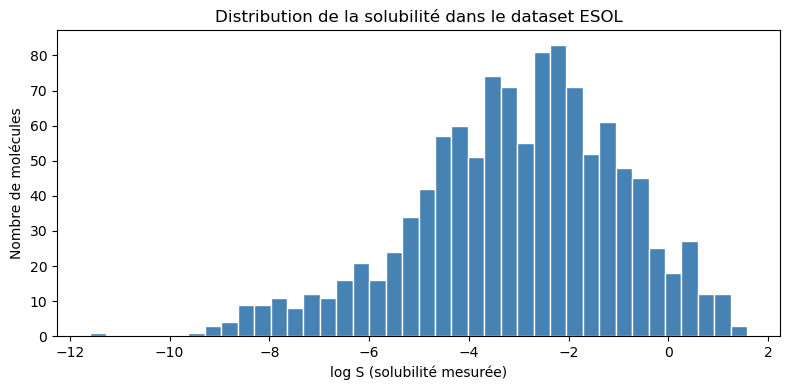

In [4]:
# Statistiques de base
print("Statistiques descriptives :")
print(df['measured log solubility in mols per litre'].describe())

# Distribution de la solubilité
plt.figure(figsize=(8, 4))
plt.hist(df['measured log solubility in mols per litre'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('log S (solubilité mesurée)')
plt.ylabel('Nombre de molécules')
plt.title('Distribution de la solubilité dans le dataset ESOL')
plt.tight_layout()
plt.show()

In [5]:
smiles = df['smiles'].iloc[0]
print(smiles)  # pour voir ce que ça donne
mol = Chem.MolFromSmiles(smiles)
print(mol)

OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 


In [6]:
logP = Descriptors.MolLogP(mol)
print(f"LogP de l'Amygdaline : {logP}")

LogP de l'Amygdaline : -3.1080199999999985


## 4. Calcul des descripteurs moléculaires
Chaque molécule est représentée par 6 descripteurs physicochimiques calculés depuis son SMILES via RDKit :
- **LogP** : lipophilie (partition octanol/eau)
- **MolWt** : masse molaire
- **NumHDonors / NumHAcceptors** : liaisons hydrogène (proticité)
- **TPSA** : surface polaire topologique
- **NumAromaticRings** : nombre de cycles aromatiques

In [7]:
def calculer_descripteurs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # si le SMILES est invalide
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

# Appliquer sur toutes les molécules
descripteurs = df['smiles'].apply(calculer_descripteurs)
descripteurs_df = pd.DataFrame(descripteurs.tolist())
print(descripteurs_df.head())

      LogP    MolWt  NumHDonors  NumHAcceptors    TPSA  NumAromaticRings
0 -3.10802  457.432           7             12  202.32                 1
1  2.84032  201.225           1              2   42.24                 2
2  2.87800  152.237           0              1   17.07                 0
3  6.29940  278.354           0              0    0.00                 5
4  1.74810   84.143           0              1    0.00                 1


In [8]:
dataset = pd.concat([descripteurs_df, df['measured log solubility in mols per litre']], axis=1)
dataset.columns = [*descripteurs_df.columns, 'logS']
print(dataset.shape)
dataset.head()

(1128, 7)


,LogP,MolWt,NumHDonors,NumHAcceptors,TPSA,NumAromaticRings,logS
0,-3.10802,457.432,7,12,202.32,1,-0.77
1,2.84032,201.225,1,2,42.24,2,-3.30
2,2.87800,152.237,0,1,17.07,0,-2.06
3,6.29940,278.354,0,0,0.00,5,-7.87
4,1.74810,84.143,0,1,0.00,1,-1.33


## 5. Modélisation ML
Deux approches comparées :
- **Régression linéaire** : modèle de référence simple
- **Random Forest** : modèle non-linéaire, mieux adapté aux relations complexes entre descripteurs et solubilité

Split 80/20 avec random_state=42 pour reproductibilité.

In [9]:
# Séparer X et y
X = dataset.drop(columns=['logS'])  # toutes les colonnes sauf logS
y = dataset['logS']  # juste logS

# Séparer train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} molécules")
print(f"Test : {X_test.shape[0]} molécules")

Train : 902 molécules
Test : 226 molécules


In [10]:
# Modèle 1 - Régression linéaire
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Modèle 2 - Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Modèles entraînés !")

Modèles entraînés !


In [11]:
# Prédictions sur le test
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Métriques
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Régression linéaire → R² : {r2_lr:.3f} | RMSE : {rmse_lr:.3f}")
print(f"Random Forest       → R² : {r2_rf:.3f} | RMSE : {rmse_rf:.3f}")

Régression linéaire → R² : 0.765 | RMSE : 1.054
Random Forest       → R² : 0.859 | RMSE : 0.816


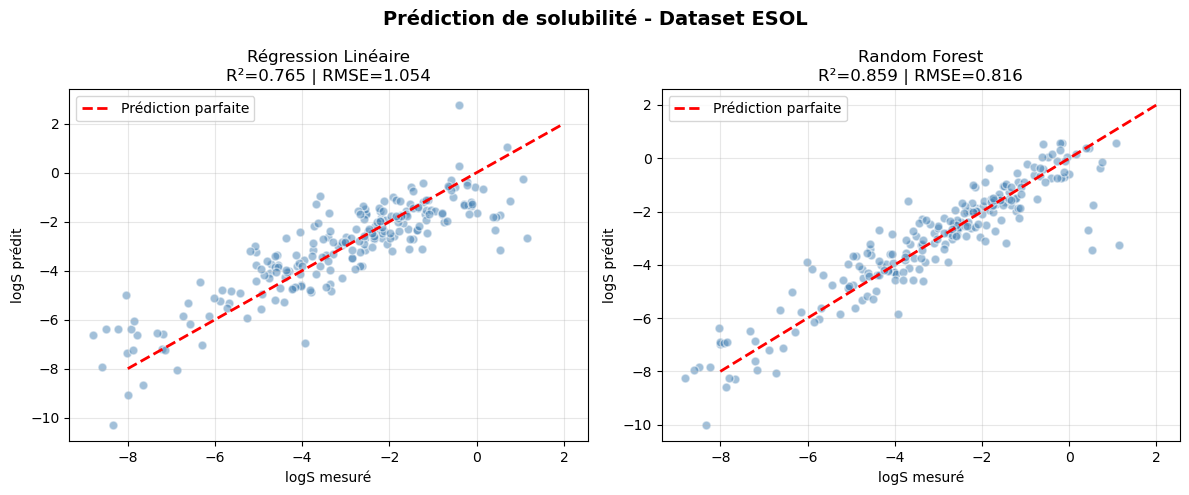

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Régression Linéaire', 'Random Forest'],
    [r2_lr, r2_rf],
    [rmse_lr, rmse_rf]
):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2, label='Prédiction parfaite')
    ax.set_xlabel('logS mesuré')
    ax.set_ylabel('logS prédit')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Prédiction de solubilité - Dataset ESOL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# 1. Calculer les descripteurs de l'aspirine
aspirine_smiles = "CC(=O)Oc1ccccc1C(=O)O"
descripteurs_aspirine = calculer_descripteurs(aspirine_smiles)
print("Descripteurs :", descripteurs_aspirine)

# 2. Mettre dans un DataFrame
X_aspirine = pd.DataFrame([descripteurs_aspirine])

# 3. Prédire
logS_aspirine = model_rf.predict(X_aspirine)
print(f"logS prédit : {logS_aspirine[0]:.3f}")
print(f"logS expérimental : -1.13")
print(f"Erreur : {abs(logS_aspirine[0] - (-1.13)):.3f}")

Descripteurs : {'LogP': 1.3101, 'MolWt': 180.15899999999996, 'NumHDonors': 1, 'NumHAcceptors': 3, 'TPSA': 63.60000000000001, 'NumAromaticRings': 1}
logS prédit : -1.860
logS expérimental : -1.13
Erreur : 0.730


## 6. Amélioration : Morgan Fingerprints
Les descripteurs globaux ne capturent pas les motifs structuraux locaux.
Les Morgan fingerprints (rayon=2, 2048 bits) encodent la présence/absence de sous-structures
autour de chaque atome. Combinés aux descripteurs, ils enrichissent la représentation moléculaire.

| Modèle | R² | RMSE |
|---|---|---|
| Régression linéaire | 0.765 | 1.054 |
| Random Forest (descripteurs) | 0.859 | 0.816 |
| Random Forest (fp + descripteurs) | 0.866 | 0.795 |

In [14]:
from rdkit.Chem import AllChem
import numpy as np

def calculer_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

# Test sur l'Amygdaline
fp_test = calculer_fingerprint(df['smiles'].iloc[0])
print(f"Taille du fingerprint : {fp_test.shape}")
print(f"Bits actifs : {fp_test.sum()} sur {len(fp_test)}")

Taille du fingerprint : (2048,)
Bits actifs : 44 sur 2048


In [15]:
# Calculer les fingerprints pour toutes les molécules
fp_matrix = np.array([calculer_fingerprint(s) for s in df['smiles']])
print(f"Matrice de fingerprints : {fp_matrix.shape}")

# Combiner fingerprints + descripteurs
X_combined = np.hstack([fp_matrix, descripteurs_df.values])
print(f"Dataset combiné : {X_combined.shape}")

y = dataset['logS'].values

Matrice de fingerprints : (1128, 2048)
Dataset combiné : (1128, 2054)


In [16]:
# Split train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Entraîner Random Forest
model_rf_combined = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_combined.fit(X_train_c,y_train_c)

# Évaluer
y_pred_combined = model_rf_combined.predict(X_test_c)
r2_combined = r2_score(y_test_c, y_pred_combined)
rmse_combined = np.sqrt(mean_squared_error(y_test_c, y_pred_combined))

print(f"RF descripteurs seuls  → R² : {r2_rf:.3f} | RMSE : {rmse_rf:.3f}")
print(f"RF combiné (fp+desc)   → R² : {r2_combined:.3f} | RMSE : {rmse_combined:.3f}")

RF descripteurs seuls  → R² : 0.859 | RMSE : 0.816
RF combiné (fp+desc)   → R² : 0.866 | RMSE : 0.795


## 7. Conclusions et perspectives
Le Random Forest avec fingerprints donne les meilleures performances (R²=0.866, RMSE=0.795),
proche du niveau de bruit expérimental des données de solubilité (±0.7 logS).

**Limites identifiées :**
- Mauvaises prédictions pour logS > 0 (peu d'exemples dans le dataset)
- Descripteurs purement 2D — pas d'énergie de solvatation ni de point de fusion

**Prochaines étapes :**
- Ajout de XGBoost
- Extension à la solubilité dans les solvants organiques

In [17]:
from xgboost import XGBRegressor

# Entraîner XGBoost
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train_c, y_train_c)

# Évaluer
y_pred_xgb = model_xgb.predict(X_test_c)
r2_xgb = r2_score(y_test_c, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_c, y_pred_xgb))

print(f"RF combiné (fp+desc)   → R² : {r2_combined:.3f} | RMSE : {rmse_combined:.3f}")
print(f"XGBoost combiné        → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")

RF combiné (fp+desc)   → R² : 0.866 | RMSE : 0.795
XGBoost combiné        → R² : 0.879 | RMSE : 0.757


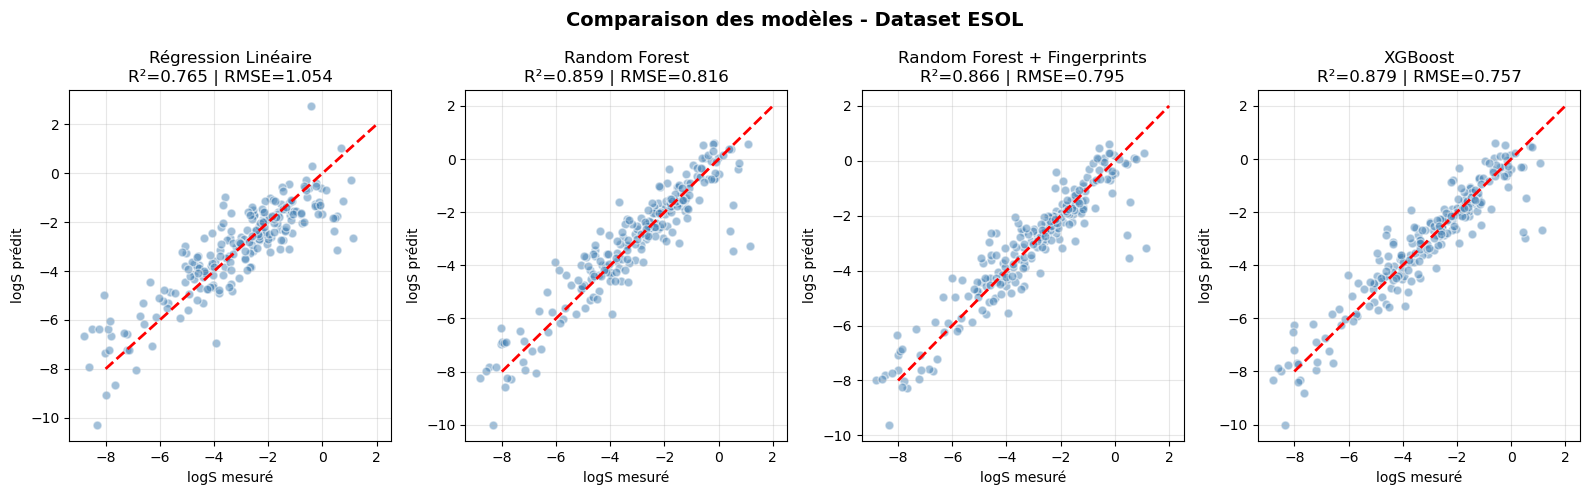

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_combined, y_pred_xgb],  # 4 vecteurs de prédictions
    ['Régression Linéaire', 'Random Forest', 'Random Forest + Fingerprints', 'XGBoost'],  # 4 titres
    [r2_lr, r2_rf, r2_combined, r2_xgb],  # 4 valeurs R²
    [rmse_lr, rmse_rf, rmse_combined, rmse_xgb],  # 4 valeurs RMSE
):
    ax.scatter(y_test_c, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS mesuré')
    ax.set_ylabel('logS prédit')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison des modèles - Dataset ESOL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()